# 05 — Model Evaluation
## LLM Lie Detector | Hallucination Detection Pipeline

This notebook evaluates the fine-tuned Llama 3.2 3B model on the validation set,
computing classification metrics and comparing against a naive baseline.

### Goals
- Load the fine-tuned LoRA adapter
- Run inference on the validation set
- Compute F1, precision, recall, and confusion matrix
- Compare against a baseline (majority class predictor)

In [1]:
import os
os.environ["PYTHONUTF8"] = "1"

from dotenv import load_dotenv
import wandb

load_dotenv('../.env')
wandb.login()
print("W&B login successful.")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: itstamimmirza (itstamimmirza-rwth-aachen-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B login successful.


In [2]:
import torch
import pandas as pd
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score, 
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful.")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

All imports successful.
CUDA available: True
GPU: NVIDIA GeForce RTX 4080 Laptop GPU


In [3]:
from huggingface_hub import login
login()

model_id = "meta-llama/Llama-3.2-3B-Instruct"
adapter_path = "../outputs/checkpoints"

# Find the best checkpoint
import os
checkpoints = [f for f in os.listdir(adapter_path) if f.startswith("checkpoint")]
checkpoints.sort()
best_checkpoint = os.path.join(adapter_path, checkpoints[-1])
print(f"Loading checkpoint: {best_checkpoint}")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

# Load base model
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    dtype=torch.bfloat16,
    device_map="auto"
)

# Load LoRA adapter on top
model = PeftModel.from_pretrained(base_model, best_checkpoint)
model.eval()

print(f"\nFine-tuned model loaded.")
print(f"VRAM: {torch.cuda.memory_allocated(0) / 1e9:.1f} GB")

Loading checkpoint: ../outputs/checkpoints\checkpoint-896


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

W0427 15:26:31.610000 4704 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels



Fine-tuned model loaded.
VRAM: 6.4 GB


In [4]:
# Recreate validation set
df = pd.read_csv('../data/combined_dataset.csv')
_, val_df = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    stratify=df['label']
)
val_df = val_df.reset_index(drop=True)

print(f"Validation samples: {len(val_df)}")

# Inference function
def predict(question, answer, max_new_tokens=10):
    prompt = f"Question: {question}\nAnswer: {answer}\nVerdict:"
    
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=0.1,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )
    
    response = tokenizer.decode(
        output[0][inputs['input_ids'].shape[-1]:],
        skip_special_tokens=True
    ).strip().upper()
    
    # Extract label
    if "HALLUCINATED" in response:
        return 1
    elif "TRUTHFUL" in response:
        return 0
    else:
        return -1  # couldn't parse

print("Inference function ready.")

Validation samples: 1592
Inference function ready.


In [5]:
print("Running inference on validation set...")
print("This will take a few minutes — 1592 samples at ~10 tokens each\n")

predictions = []
true_labels = []
unparseable = 0

for i, row in val_df.iterrows():
    pred = predict(row['question'], row['answer'])
    predictions.append(pred)
    true_labels.append(row['label'])
    
    if pred == -1:
        unparseable += 1
    
    # Progress update every 100 samples
    if (i + 1) % 100 == 0:
        print(f"Progress: {i+1}/1592 samples processed")

print(f"\nDone.")
print(f"Unparseable responses: {unparseable} ({unparseable/len(val_df)*100:.1f}%)")

Running inference on validation set...
This will take a few minutes — 1592 samples at ~10 tokens each

Progress: 100/1592 samples processed
Progress: 200/1592 samples processed
Progress: 300/1592 samples processed
Progress: 400/1592 samples processed
Progress: 500/1592 samples processed
Progress: 600/1592 samples processed
Progress: 700/1592 samples processed
Progress: 800/1592 samples processed
Progress: 900/1592 samples processed
Progress: 1000/1592 samples processed
Progress: 1100/1592 samples processed
Progress: 1200/1592 samples processed
Progress: 1300/1592 samples processed
Progress: 1400/1592 samples processed
Progress: 1500/1592 samples processed

Done.
Unparseable responses: 0 (0.0%)


In [6]:
# Filter out unparseable (-1) just in case
valid_idx = [i for i, p in enumerate(predictions) if p != -1]
preds_clean = [predictions[i] for i in valid_idx]
labels_clean = [true_labels[i] for i in valid_idx]

# Core metrics
f1 = f1_score(labels_clean, preds_clean, average='weighted')
precision = precision_score(labels_clean, preds_clean, average='weighted')
recall = recall_score(labels_clean, preds_clean, average='weighted')

print("=" * 40)
print("FINE-TUNED MODEL RESULTS")
print("=" * 40)
print(f"F1 Score:  {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print()
print("Classification Report:")
print(classification_report(labels_clean, preds_clean, 
                           target_names=['TRUTHFUL', 'HALLUCINATED']))

FINE-TUNED MODEL RESULTS
F1 Score:  0.9032
Precision: 0.9078
Recall:    0.9033

Classification Report:
              precision    recall  f1-score   support

    TRUTHFUL       0.86      0.95      0.90       759
HALLUCINATED       0.95      0.86      0.90       833

    accuracy                           0.90      1592
   macro avg       0.91      0.91      0.90      1592
weighted avg       0.91      0.90      0.90      1592



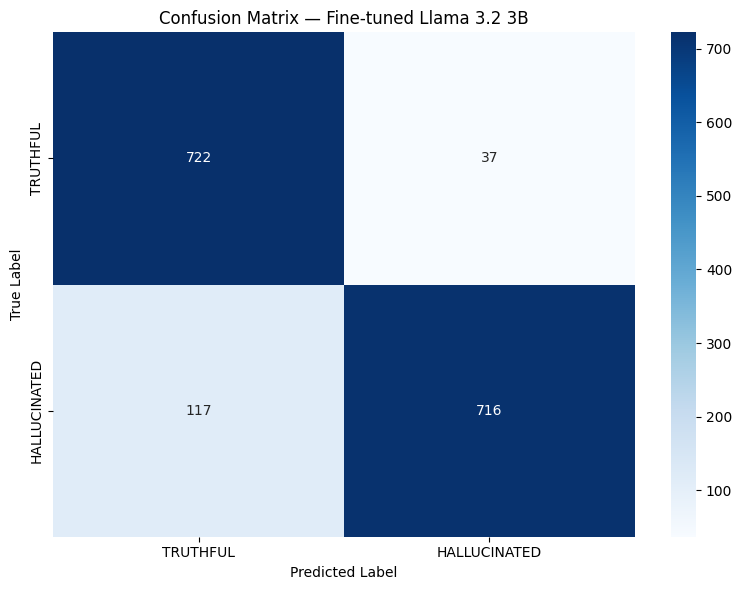

Saved to outputs/confusion_matrix.png


In [7]:
# Confusion matrix
cm = confusion_matrix(labels_clean, preds_clean)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['TRUTHFUL', 'HALLUCINATED'],
            yticklabels=['TRUTHFUL', 'HALLUCINATED'])
plt.title('Confusion Matrix — Fine-tuned Llama 3.2 3B')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150)
plt.show()
print("Saved to outputs/confusion_matrix.png")

In [8]:
# Naive baseline — always predict the majority class (HALLUCINATED = 1)
baseline_preds = [1] * len(labels_clean)

baseline_f1 = f1_score(labels_clean, baseline_preds, average='weighted')
baseline_precision = precision_score(labels_clean, baseline_preds, average='weighted')
baseline_recall = recall_score(labels_clean, baseline_preds, average='weighted')

print("=" * 40)
print("BASELINE (Always predict HALLUCINATED)")
print("=" * 40)
print(f"F1 Score:  {baseline_f1:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall:    {baseline_recall:.4f}")

print("\n" + "=" * 40)
print("COMPARISON")
print("=" * 40)
print(f"{'Metric':<12} {'Baseline':>10} {'Our Model':>10} {'Improvement':>12}")
print("-" * 46)
print(f"{'F1':<12} {baseline_f1:>10.4f} {f1:>10.4f} {f1-baseline_f1:>+12.4f}")
print(f"{'Precision':<12} {baseline_precision:>10.4f} {precision:>10.4f} {precision-baseline_precision:>+12.4f}")
print(f"{'Recall':<12} {baseline_recall:>10.4f} {recall:>10.4f} {recall-baseline_recall:>+12.4f}")

BASELINE (Always predict HALLUCINATED)
F1 Score:  0.3595
Precision: 0.2738
Recall:    0.5232

COMPARISON
Metric         Baseline  Our Model  Improvement
----------------------------------------------
F1               0.3595     0.9032      +0.5438
Precision        0.2738     0.9078      +0.6340
Recall           0.5232     0.9033      +0.3800


c:\ML Projects\llm-lie-detector\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [9]:
# Save results to file
import json

results = {
    "model": "Llama-3.2-3B-Instruct fine-tuned with LoRA",
    "dataset": "TruthfulQA + HaluEval (15,918 training pairs)",
    "validation_samples": len(labels_clean),
    "fine_tuned_model": {
        "f1": round(f1, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "accuracy": round(sum(p == l for p, l in zip(preds_clean, labels_clean)) / len(labels_clean), 4)
    },
    "baseline": {
        "f1": round(baseline_f1, 4),
        "precision": round(baseline_precision, 4),
        "recall": round(baseline_recall, 4)
    },
    "improvement": {
        "f1": round(f1 - baseline_f1, 4),
        "precision": round(precision - baseline_precision, 4),
        "recall": round(recall - baseline_recall, 4)
    }
}

with open('../outputs/evaluation_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Results saved to outputs/evaluation_results.json")
print(json.dumps(results, indent=2))

Results saved to outputs/evaluation_results.json
{
  "model": "Llama-3.2-3B-Instruct fine-tuned with LoRA",
  "dataset": "TruthfulQA + HaluEval (15,918 training pairs)",
  "validation_samples": 1592,
  "fine_tuned_model": {
    "f1": 0.9032,
    "precision": 0.9078,
    "recall": 0.9033,
    "accuracy": 0.9033
  },
  "baseline": {
    "f1": 0.3595,
    "precision": 0.2738,
    "recall": 0.5232
  },
  "improvement": {
    "f1": 0.5438,
    "precision": 0.634,
    "recall": 0.38
  }
}
